In [18]:
#
# This notebook provides a sample of visualization of model performance
# Experiments performed Summer2024 can be found casper:/glade/campaign/ral/wsap/oracleMLSL/data/model_output/
# Import all the libraries used in this notebook
# from pvlib.solarposition import get_solarposition
import datetime
import os
from glob import glob
from os.path import join
from plotly.offline import init_notebook_mode, iplot
init_notebook_mode(connected=True)
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt
import plotly 
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objs as go
from  plotly.graph_objs import *
import plotly.io as pio
pio.renderers.default = 'iframe'


print(os.environ["CONDA_DEFAULT_ENV"])  # Check the name of the current Conda environment

/glade/work/dettling/conda-envs/plotlyenv


In [19]:
# Adjust display settings to prevent line wrapping
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_rows', None)


In [57]:
#
# After running train_offshore_models_mvco.py ../config/offshore_surface_layer_training_mvco.yml
# Read in the predictions from the test data
#

# variables needed to make this notebook work for the QC MVCO dataset
predictand1 = 'momentum_flux'
exact_predictand1 = "momentum_flux:18.4_m:m2_s-2"
#predictand2 = 'heat_flux'
#exact_predictand2 = 'heat_flux:18.4_m:degrees_C_m_s-1' # degrees celsius , meters per second
mo_version = 'MOST_momentum_flux:18.4_m:m2_s-2'


In [ ]:
# import the calc_mean_metrics_kfold() function that currently exists on HPC only

In [22]:
# Initialize an empty list to store dataframes
df_list = []

# Loop through the k-folds (0 to 9)
for num in range(10):
    # Construct the file path
    file_path = f'data/final_nn_mf_derivs_sfcVars_ltd_noDir/model_QC_--kfold-{num}/surface_layer_model_metrics.csv'
    
    # Read the CSV file into a dataframe
    df = pd.read_csv(file_path)
    
    # Add a column to identify the k-fold
    df['kfold'] = num
    
    # Append the dataframe to the list
    df_list.append(df)

# Concatenate all dataframes in the list into a single dataframe
combined_df = pd.concat(df_list, ignore_index=True)

# Compute the average of the metrics across all folds
average_metrics = combined_df.groupby('Model').mean().reset_index()

all_metrics = pd.concat([combined_df, average_metrics], ignore_index=True)

# Save the result to a new CSV file
# average_metrics.to_csv('average_metrics.csv', index=False)
all_metrics.to_csv('data/final_nn_mf_derivs_sfcVars_ltd_noDir/all_metrics.csv', index=False)


### loss function graph for NN

In [31]:
def draw_loss(cut, direc, j=' ', save_path=None, show=True):
    model_types = [predictand1]

    fig, axs = plt.subplots(1, len(model_types), figsize = (6,3))
    #ax = axs.flatten()
    ax = np.atleast_1d(axs)
    for i in range(len(ax)):
        df = pd.read_csv(direc + '/' + model_types[i] + '-neural_network_training_history.csv')

        ax[i].plot(df[cut:].index, df['loss'][cut:], label='loss')
        ax[i].plot(df[cut:].index, df['val_loss'][cut:], label='val_loss')
        ax[i].set_title('{0} loss {1}'.format(model_types[i], j), fontsize=11)
        ax[i].legend(loc='upper center', bbox_to_anchor=(0.5,-0.2), fancybox=True, ncol=1)

    if save_path:
        plt.savefig(f'{save_path}/loss_kfold-{j}_.png')

    if show == True: 
        plt.show()

    plt.close()


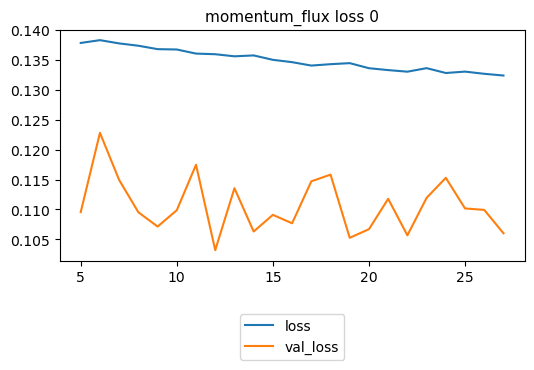

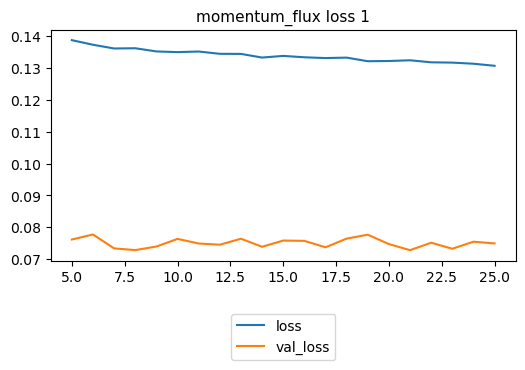

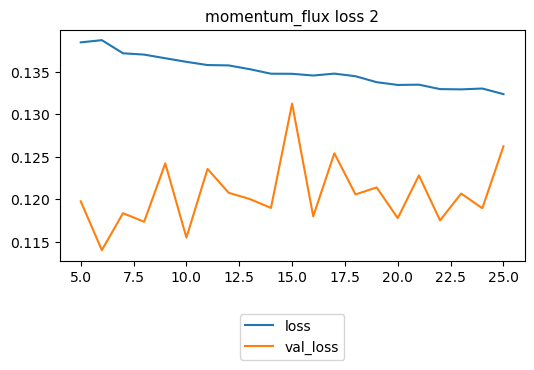

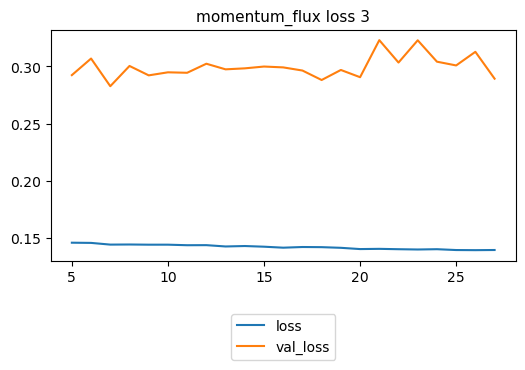

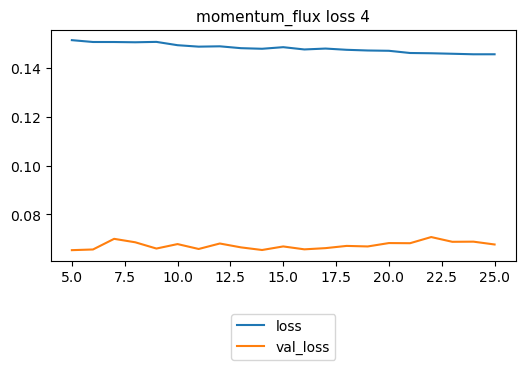

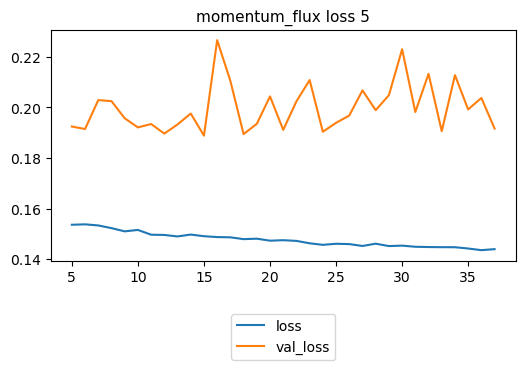

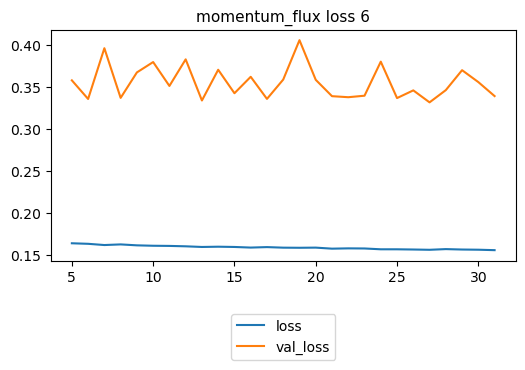

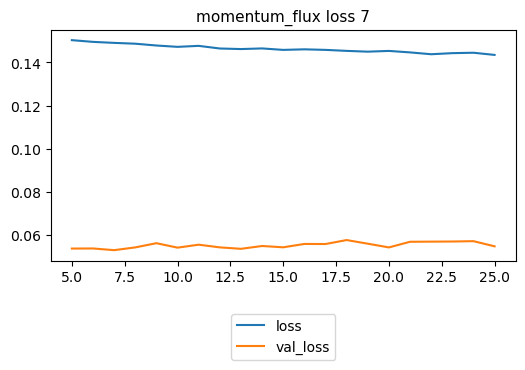

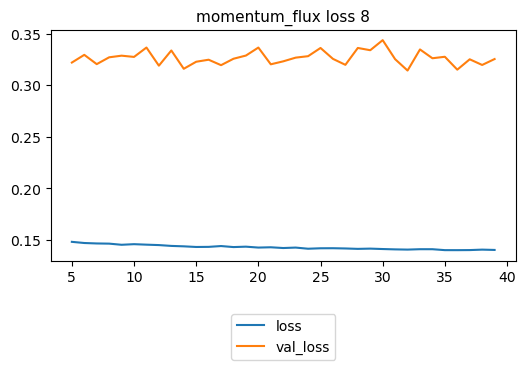

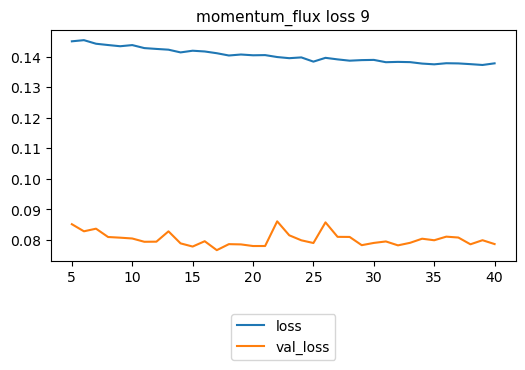

In [33]:

for i in range(10):
    draw_loss(5, 'data/final_nn_mf_derivs_sfcVars_ltd_noDir/model_QC_--kfold-{0}'.format(i), i,  save_path=None, show=True)


In [38]:

#
# Define this time series layout once, will use again in time series plots in rest of notebook 
#
timeSeriesLayout = dict(
    title='Time Series with Rangeslider',
    xaxis=dict(
        rangeselector=dict(
            buttons=list([
                dict(count =1,
                    label='1d',
                    step='day',
                    stepmode='forward'),
                dict(count=7,
                     label='1w',
                     step='week',
                     stepmode='forward'),
                dict(count=30,
                     label='1m',
                     step='month',
                     stepmode='forward'),
                dict(step='all')
            ])
        ),
        rangeslider=dict(),
        type='date'
    )
)


In [42]:
# the ANN scales the values and predictions so one must keep track of the scaling  mean and bias
# unless train_offshore_models_mvco.py handles the application to the ANN result
import pandas as pd
#
# After running train_offshore_models_mvco.py ../config/offshore_surface_layer_training_mvco.yml
# Read in the predictions from the test data
# for i in range(10):
for i in range(1):

    directory = f'data/final_nn_mf_derivs_sfcVars_ltd_noDir/model_QC_--kfold-{i}'
    scalesUstar = pd.read_csv(directory + "/" + predictand1 + "_scale_values.csv")
    meanUstar = scalesUstar['mean'].iloc[len(scalesUstar.index) -1]
    scaleUstar = scalesUstar['scale'].iloc[len(scalesUstar.index) -1]
    print(f'fold{i}:')
    print("meanUstar",meanUstar)
    print("scaleUstar",scaleUstar)
    print("")

fold0:
meanUstar 0.0780309653916211
scaleUstar 0.1061946649957854



In [48]:
print(pred.columns)

Index(['Time', 'momentum_flux-neural_network', 'momentum_flux-mo', 'temperature:18.4_m:K', 'water_sfc_temperature:0_m:K', 'pressure:18.4_m:hPa', 'potential_temperature:18.4_m:K', 'skin_virtual_potential_temperature:0_m:K', 'mixing_ratio:0_m:g_kg-1', 'mixing_ratio:18.4_m:g_kg-1', 'relative_humidity:18.4_m:%', 'wave_direction:0_m:degrees', 'wave_height:0_m:m', 'wave_period:0_m:s', 'wave_phase_speed:0_m:m_s-1', 'near_surf_current:0_m:m_s-1', 'near_surf_current_dir:0_m:deg', 'wind_speed:18.4_m:m_s-1', 'wind_direction:18.4_m:degrees', 'angle_between_wind_wave:0_m:degrees', 'u_wind:18.4_m:m_s-1', 'v_wind:18.4_m:m_s-1', 'bulk_richardson:18.4_m:none', 'u_w:18.4_m:m2_s-2', 'v_w:18.4_m:m2_s-2', 'dT_dz:18.4_m:K_m-1', 'dSpeed_dz:18.4_m:s-1', 'MOST_momentum_flux:18.4_m:m2_s-2', 'MOST_heat_flux:18.4_m:degrees_K_m_s-1', 'MOST_chopped_momentum_flux:18.4_m:m2_s-2', 'MOST_chopped_heat_flux:18.4_m:degrees_K_m_s-1', 'MOST_rounded_momentum_flux:18.4_m:m2_s-2',
       'MOST_rounded_heat_flux:18.4_m:degrees_

In [47]:
# This is result from JUST one out of 10 folds of cross validation
pred = pd.read_csv('data/final_nn_mf_derivs_sfcVars_ltd_noDir/model_QC_--kfold-0/surface_layer_model_predictions.csv')
#pred['Time'] = pd.to_datetime(pred['Time'])
#pred.index = pred['Time']
#
# ann scaled value params for friction velocity read in above
#
predTrace1= go.Scatter(
    x =  pred.index,
    y =  pred[predictand1 + '-neural_network'],
    #y =  pred[predictand1 + '-neural_network']*scaleUstar + meanUstar,
    name = "nn u*",
    line = dict(color = 'blue'),
    connectgaps = False,
    opacity = 0.5)

predTrace2= go.Scatter(
    x =  pred.index,
    y =  pred[exact_predictand1],
    name = "measured u*",
    line = dict(color = 'red'),
    connectgaps = False,
    opacity = 0.5)

predTrace3= go.Scatter(
    x =  pred.index,
    y =  pred['MOST_momentum_flux:18.4_m:m2_s-2'],
    name = "python lib most u*",
    line = dict(color = 'green'),
    connectgaps = False,
    opacity = 0.5)

data = [predTrace1, predTrace2, predTrace3]#, predTrace4]
plotly.offline.iplot(data, filename='basic-line-plot')
layout = timeSeriesLayout


4924
4598


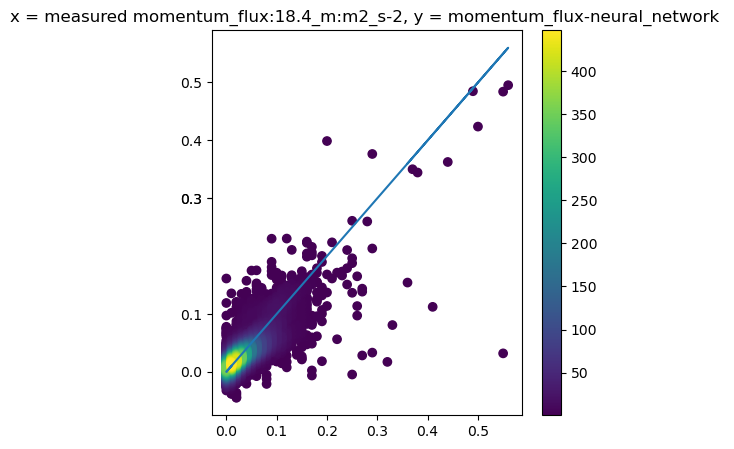

In [54]:

xStr=  exact_predictand1
yStr = predictand1 + '-neural_network'
x = pred[xStr]
y = pred[yStr]
#clr = pred['stabParm']
print( pred[yStr].loc[ pred[yStr] < .08].count())
print( pred[xStr].loc[ pred[xStr] < .08].count())
xy = np.vstack([x,y])
z = gaussian_kde(xy)(xy)
idx = z.argsort()
x, y, z = x[idx], y[idx], z[idx]
fig, ax = plt.subplots(figsize = (5,5))

im = ax.scatter(x,y, c=z )
ax.set_xticks([0,.1,.2,.3,.4,.5])
ax.set_yticks([0,.1,.3,.3,.4,.5])
fig.colorbar(im, ax = ax)
titleStr = "x = measured {0}, y = {1} ". format(xStr, yStr)
ax.set_title(titleStr )
m, b = np.polyfit(x, y, 1)
ax.plot(x, x)




0


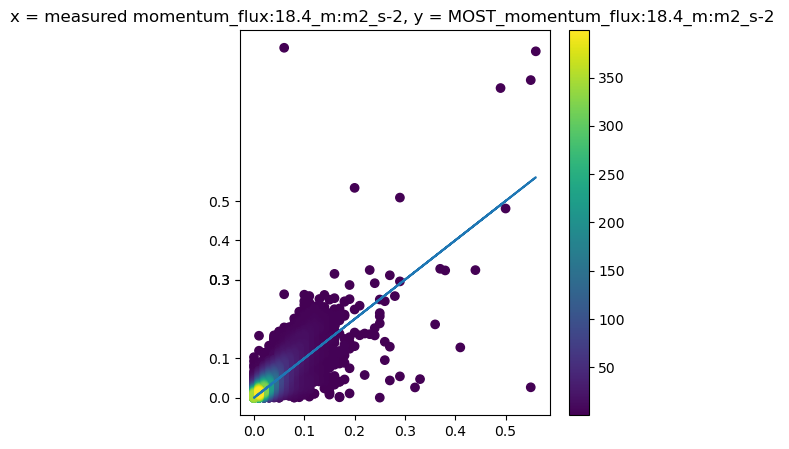

In [58]:

from scipy.stats import *
import matplotlib.pyplot as plt
import numpy as np
#
#  plot friction-vel scatter plot as computed by mo.py and make sure
#  calculations in mo.py reflect the calculations in this notebook. 
#  (I attached the columns from this notebook to the testing and training data, so the 
#.   most output can be examined as calculated in mo.py or here)
#
print(pred[mo_version].isna().sum())
pred2 = pred.loc[pred[ mo_version].isna() == False]
xStr=  exact_predictand1
yStr = mo_version
x = pred2[xStr]
y = pred2[yStr]


xy = np.vstack([x,y])
z = gaussian_kde(xy)(xy)

idx = z.argsort()
x, y,z = x[idx], y[idx], z[idx]
fig, ax = plt.subplots(figsize = (5,5))

im = ax.scatter(x,y, c=z )
ax.set_xticks([0,.1,.2,.3,.4,.5])
ax.set_yticks([0,.1,.3,.3,.4,.5])
fig.colorbar(im, ax = ax)
titleStr = "x = measured {0}, y = {1} ". format(xStr, yStr)
ax.set_title(titleStr )
m, b = np.polyfit(x, y, 1)
ax.plot(x, x)


In [69]:
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt
def draw_mf(df):
    #
    # Create some scatter plots for quick visual comparison of ML models and also MOST calcs
    #
    xStr=  exact_predictand1
    yStr = []
    yStr.append(predictand1 + '-neural_network')
    yStr.append(mo_version)

    df2 =  df.loc[df[mo_version].isna() == False]

    fig, ax = plt.subplots(1,2, figsize = (20,10))
    ax = ax.flat
    print(len(ax))
    for i in range (0,len(ax)):
        x = df2[xStr]
        y = df2[yStr[i]]

        xy = np.vstack([x,y])
        z = gaussian_kde(xy)(xy)
        idx = z.argsort()
        x, y,z = x[idx], y[idx], z[idx]
        im = ax[i].scatter(x,y,  c=z )

        fig.colorbar(im, ax = ax[i])
        titleStr = "y = {0} x = measured {1}". format(yStr[i], xStr)
        ax[i].set_title(titleStr )
        m, b = np.polyfit(x, y, 1)
        ax[i].plot(x, x)

2


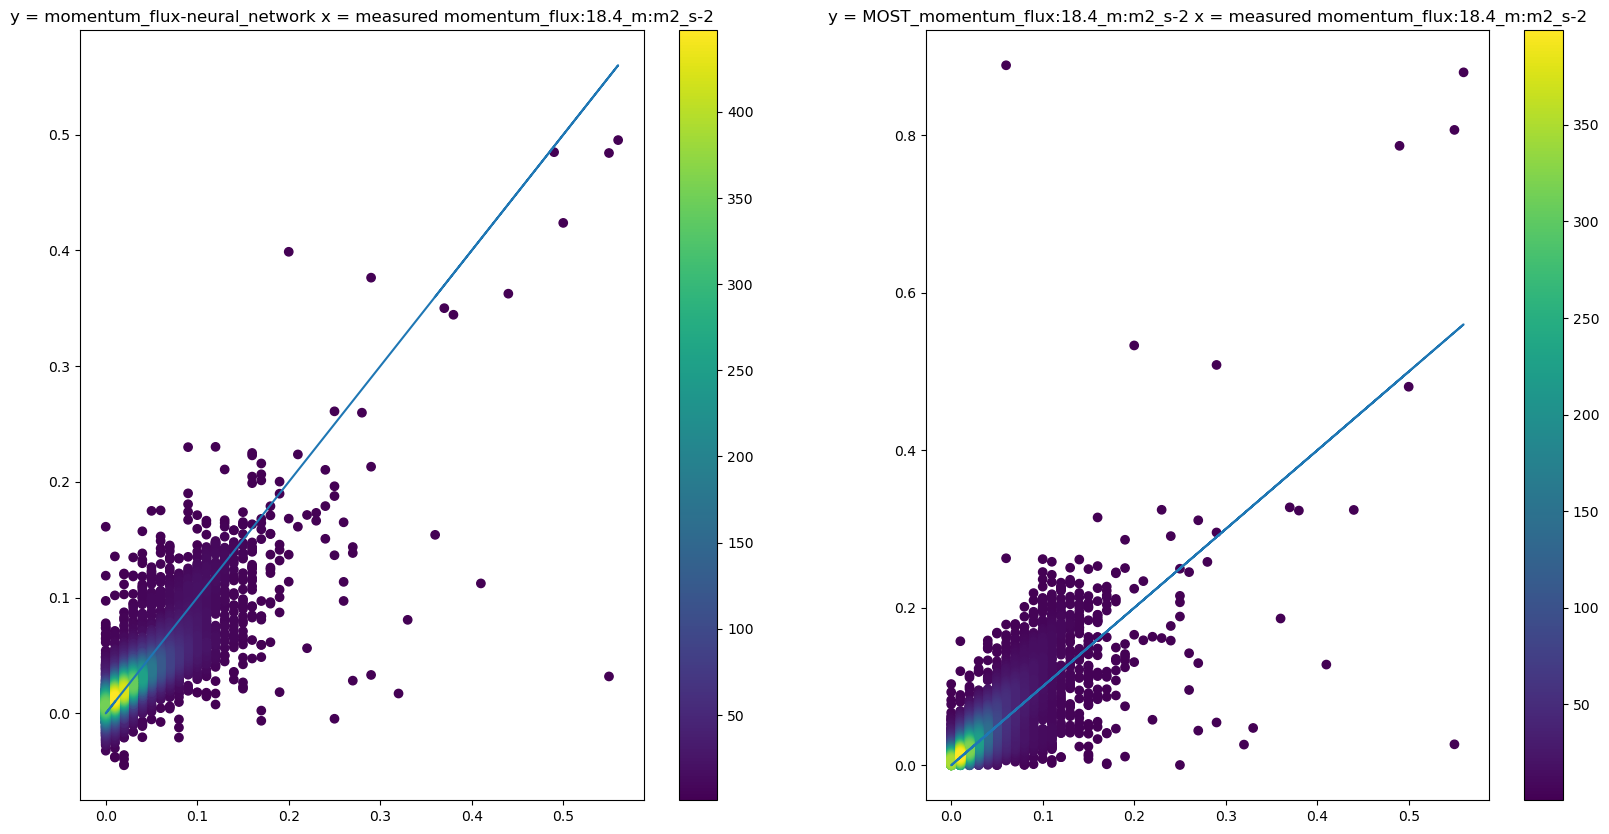

In [71]:
draw_mf(pred)

In [95]:
# not runable with the data in this repo as there is no rf, and no hf
# but left as an example
def draw_hf(df):
    #
    # Create some scatter plots for quick visual comparison of ML models and also MOST calcs
    #

    xStr = exact_predictand2

    yStr = []

    yStr.append(predictand2+ '-neural_network')
    yStr.append(predictand2+ '-random_forest')
    yStr.append( mo_version)
   

    df2 = df.loc[df[predictand2+ mo_version].isna() == False]
    df2 = df.loc[df[predictand2+ mo_version2].isna() == False]

    
    fig, ax = plt.subplots(2,2, figsize = (30,10))
    ax = ax.flat
    for i in range (0,len(ax)):
        x = df2[xStr]
        y = df2[yStr[i]]
        xy = np.vstack([x,y])
        z = gaussian_kde(xy)(xy)
        idx = z.argsort()
        x, y, z = x[idx], y[idx], z[idx]
        im = ax[i].scatter(x,y,  c=z, cmap = 'plasma')
        fig.colorbar(im, ax = ax[i])
        titleStr = "x = measured {0}, y = {1}". format(xStr, yStr[i])
        ax[i].set_title(titleStr )
        ax[i].plot(x, x)



In [ ]:
draw_hf(pred)

# test feature importance plot

In [77]:

from o_mvco_model_analysis import plot_feature_importance, average_importances

ModuleNotFoundError: No module named 'o_mvco_model_analysis'

In [86]:

num_folds = 5 # or 10
experiment = 'uv_worked_before'
directory = f"../../data/model_output/{experiment}"
modelnames = ["heat_flux_neural_network", "momentum_flux_neural_network", "heat_flux_random_forest", "momentum_flux_random_forest"]
sort = True # or False

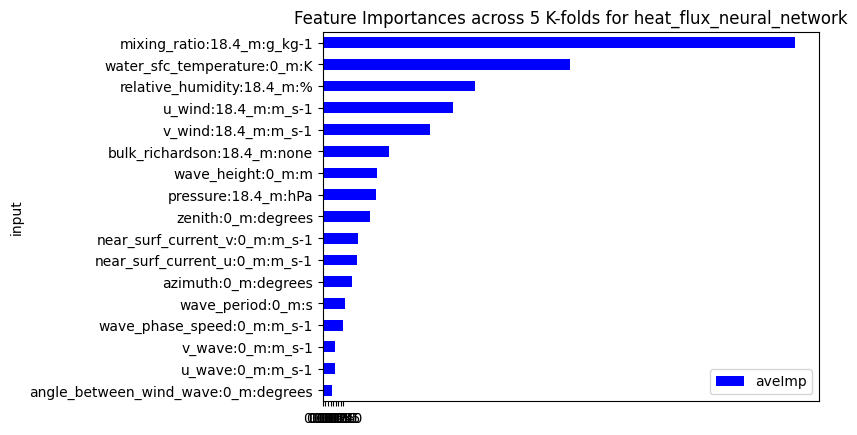

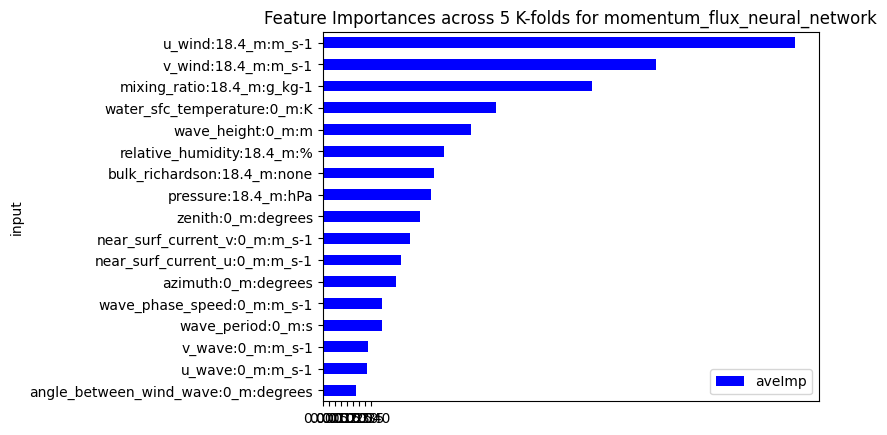

In [87]:
for model in modelnames:
    average_importances(directory, model, sorted=sort)

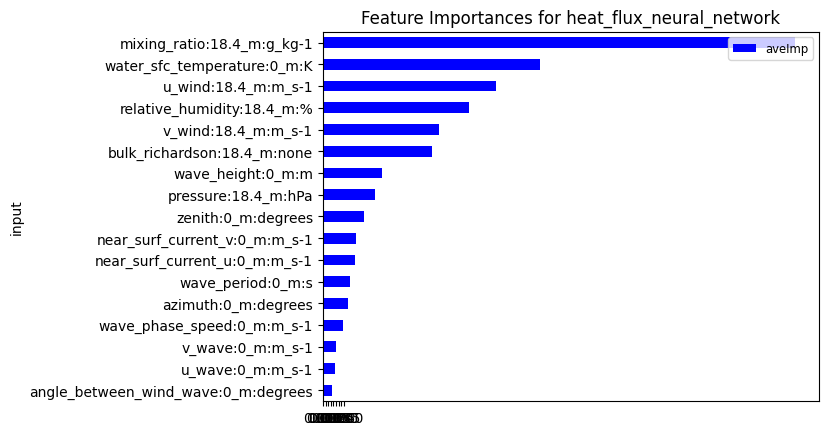

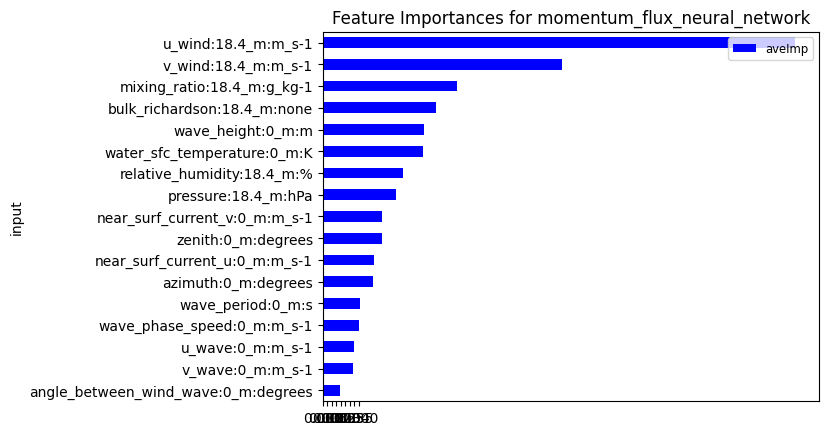

In [85]:
num = 0
for model in modelnames:
    plot_feature_importance(f"{directory}/model_QC_--kfold-{num}", model, sorted=sort)

# FINO code below

                               input    aveImp
0       sea_surface_pressure:0_m:hPa  0.008023
1            mixing_ratio:0_m:g_kg-1  0.010445
4         wave_phase_speed:0_m:m_s-1  0.020612
7  dMixingRatio_dz:18.4_m:g_kg-1_m-1  0.020946
3                  wave_period:0_m:s  0.036795
2                  wave_height:0_m:m  0.045834
6           dPotTemp_dz:18.4_m:K_m-1  0.060266
5               dSpeed_dz:18.4_m:s-1  0.425713


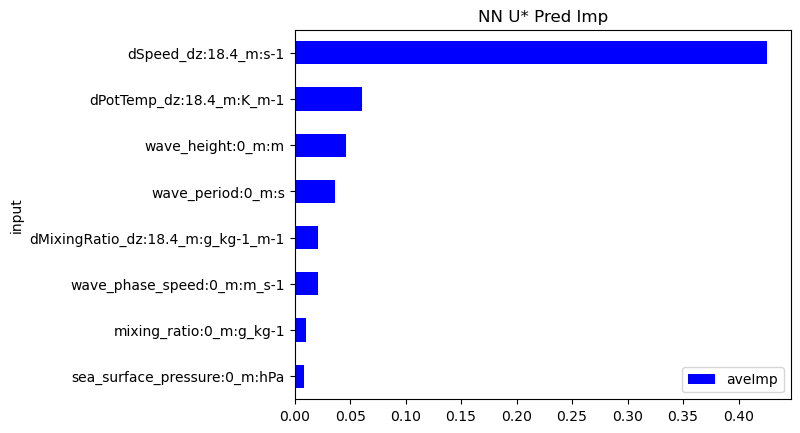

In [82]:
import pandas as pd
directory = f'data/final_nn_mf_derivs_sfcVars_ltd_noDir/model_QC_--kfold-0/'
impNn = pd.read_csv(directory + "momentum_flux_neural_network_importances.csv")

impNn['aveImp'] = abs(impNn[[ 'all_0', 'all_1', 'all_2', 'all_3', 'all_4']].mean(axis = 1 ))

print (impNn[['input', 'aveImp']].sort_values(by = 'aveImp'))

barPlotImp= impNn[['input', 'aveImp']].sort_values(by = 'aveImp')
ax = barPlotImp.plot.barh( color = 'blue',x ='input',y = 'aveImp', title =  'NN U* Pred Imp')
#ax.set_xticks([0, .005,  .01, .015,.02,.025, .03, .035,.04])

In [ ]:
import pandas as pd
impRf = pd.read_csv(directory + "/friction_velocity_random_forest_importances.csv")

impRf['aveImp'] = abs(impRf[[ 'all_0', 'all_1', 'all_2', 'all_3', 'all_4']].mean(axis = 1 ))

print (impRf[['input', 'aveImp']].sort_values(by = 'aveImp'))

barPlotImp= impRf[['input', 'aveImp']].sort_values(by = 'aveImp')
ax = barPlotImp.plot.barh( color = 'blue',x ='input',y = 'aveImp', title =  'RF U* Pred Imp')
ax.set_xticks([0, .005,  .01, .015,.02,.025, .03, .035,.04])

In [ ]:
import pandas as pd
impNn = pd.read_csv(directory + "/temp_scale_neural_network_importances.csv")


impNn['aveImp'] = abs(impNn[[ 'all_0', 'all_1', 'all_2', 'all_3', 'all_4']].mean(axis = 1 ))

print (impNn[['input', 'aveImp']].sort_values(by = 'aveImp'))

barPlotImp= impNn[['input', 'aveImp']].sort_values(by = 'aveImp')
ax = barPlotImp.plot.barh( color = 'blue',x ='input',y = 'aveImp', title =  'NN Temp Scale Pred Imp')
#ax.set_xticks([0, .005,  .01, .015,.02,.025, .03, .035,.04])

In [ ]:
import pandas as pd

impRf = pd.read_csv(directory + "/temp_scale_random_forest_importances.csv")

impRf['aveImp'] = abs(impRf[[ 'all_0', 'all_1', 'all_2', 'all_3', 'all_4']].mean(axis = 1 ))

print (impRf[['input', 'aveImp']].sort_values(by = 'aveImp'))

barPlotImp= impRf[['input', 'aveImp']].sort_values(by = 'aveImp')
ax = barPlotImp.plot.barh( color = 'blue',x ='input',y = 'aveImp', title =  'RF Temp Scale Pred Imp')
ax.set_xticks([0, .005,  .01, .015,.02,.025, .03, .035,.04])

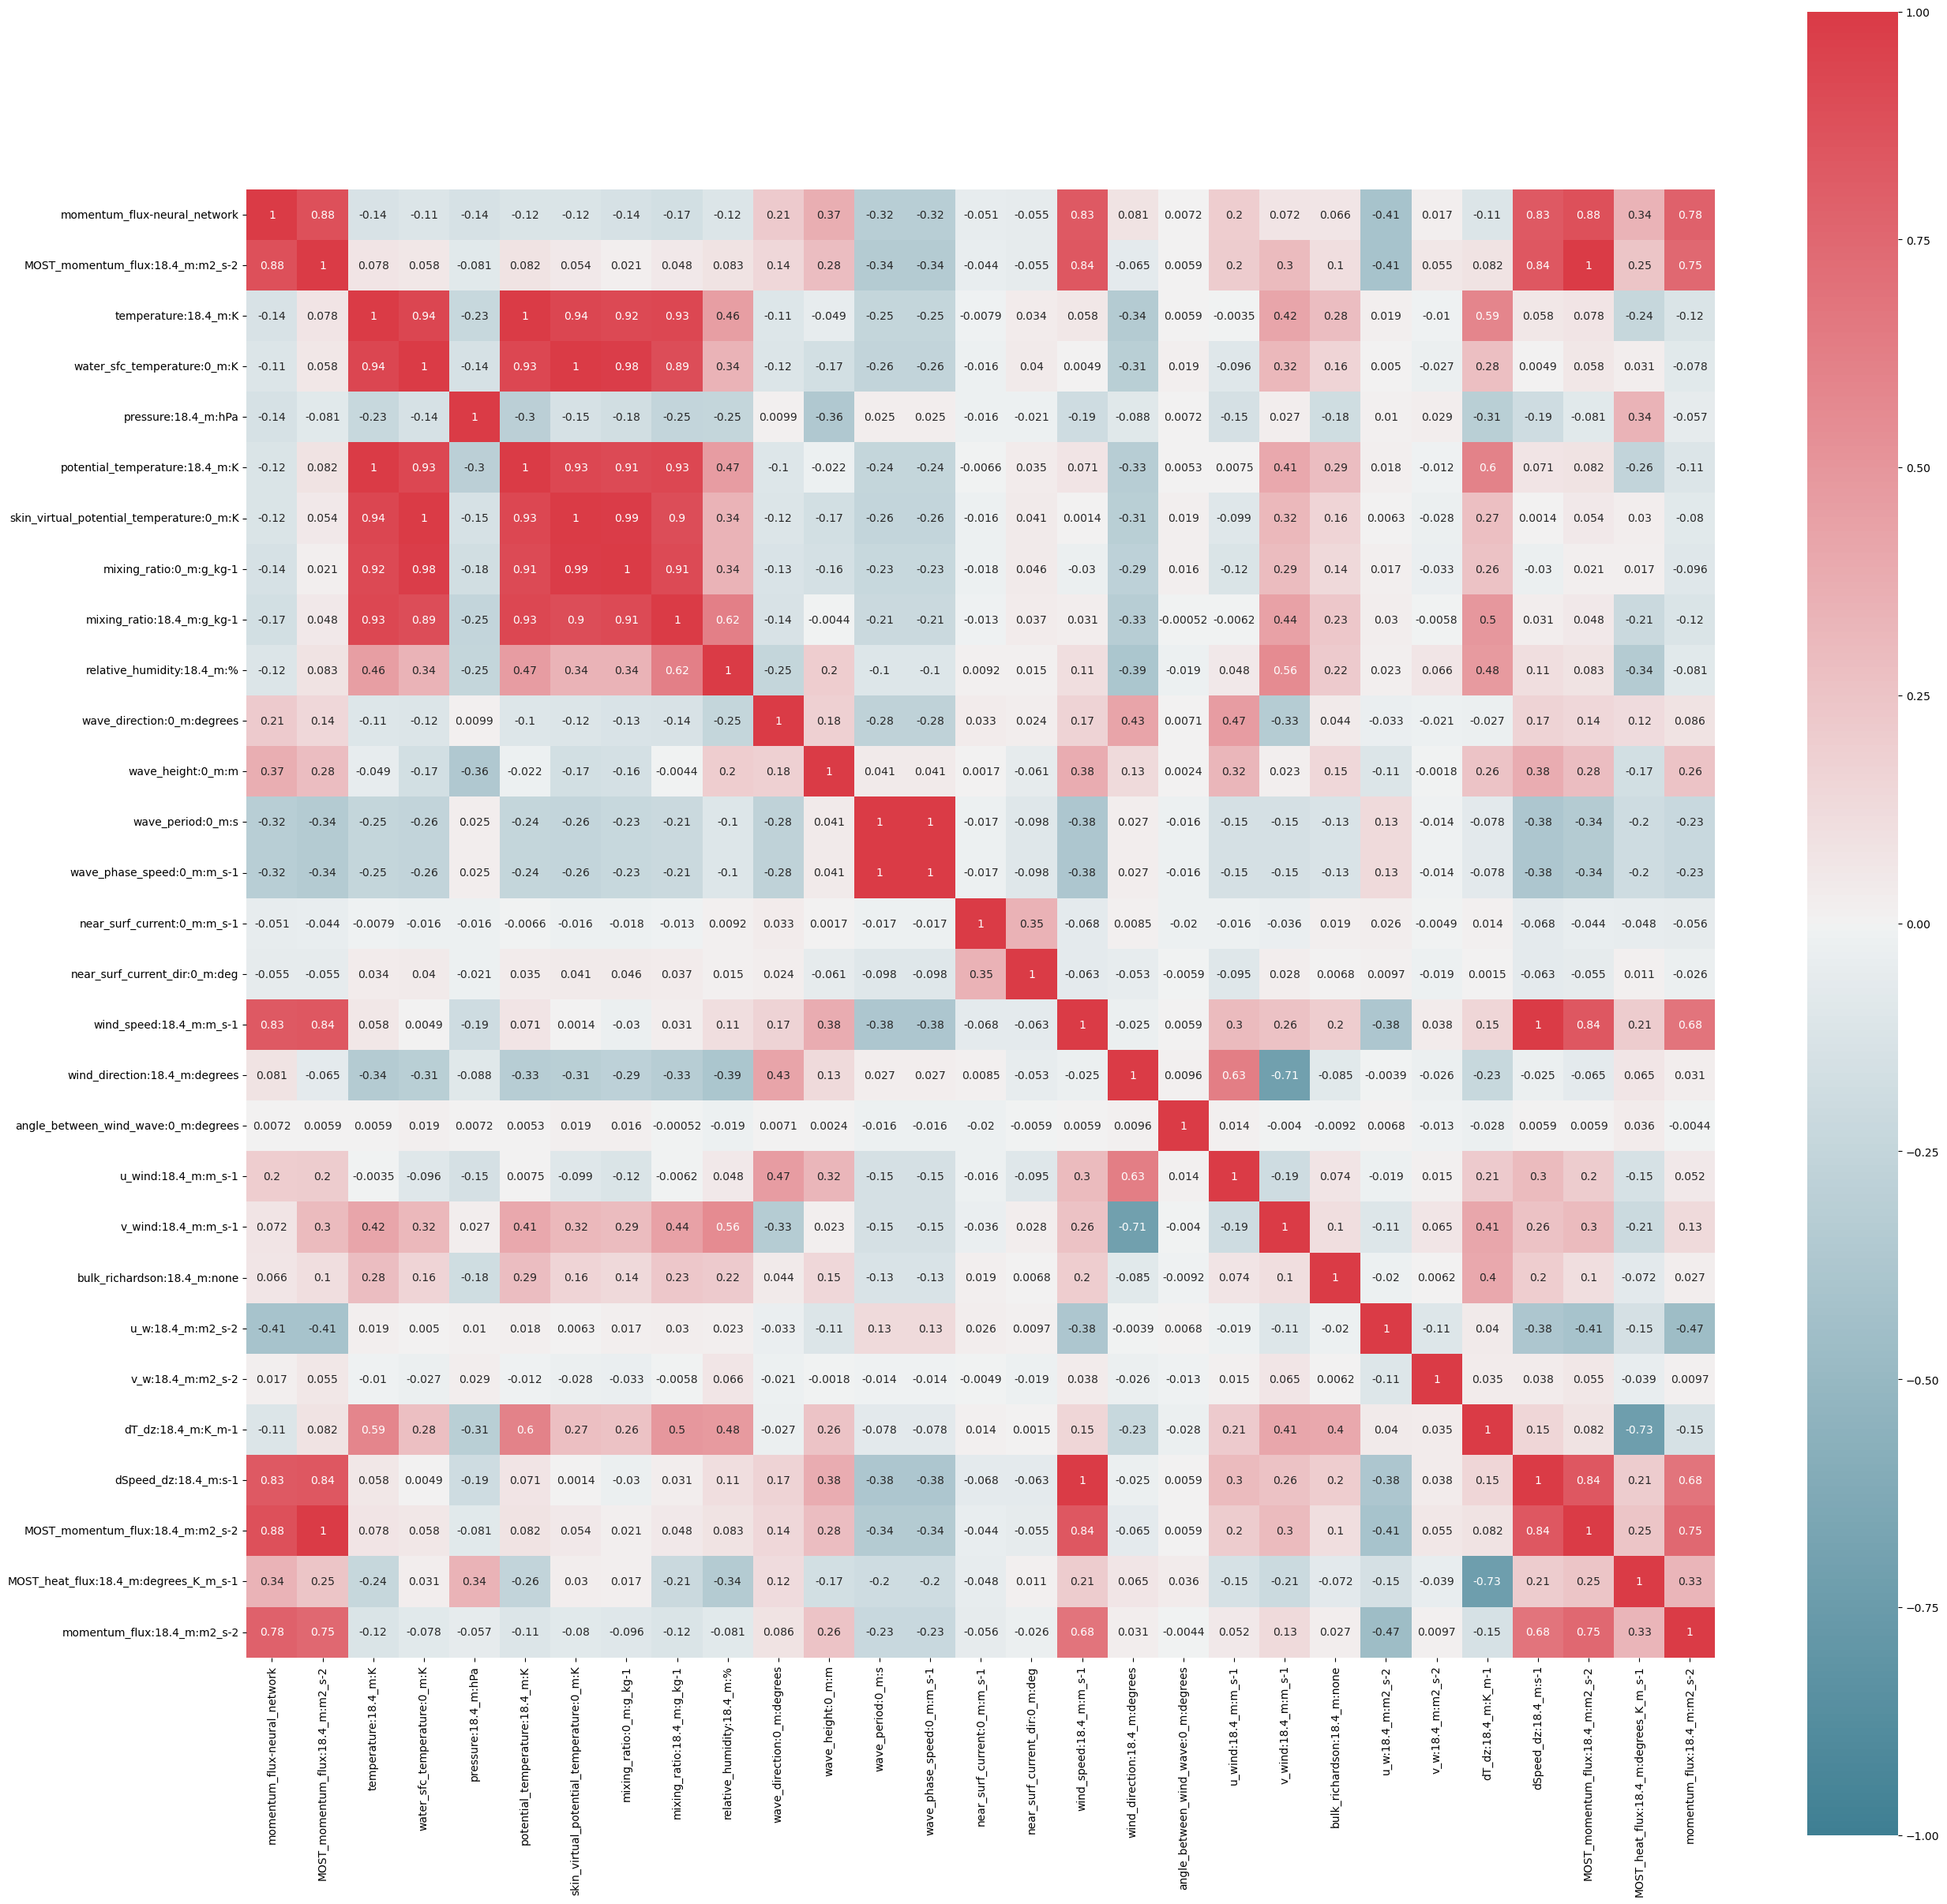

In [90]:
#
# Look at correlation of predictors and predictand -- this is just an example of how to form a correlation heat map
# 
#
import seaborn as sns
import matplotlib.pyplot as plt


#
# Correlation map
# 
f, ax = plt.subplots(figsize=(30, 30))


corr = pred[[ 'momentum_flux-neural_network', 'MOST_momentum_flux:18.4_m:m2_s-2', 'temperature:18.4_m:K', 'water_sfc_temperature:0_m:K', 'pressure:18.4_m:hPa', 'potential_temperature:18.4_m:K', 'skin_virtual_potential_temperature:0_m:K', 'mixing_ratio:0_m:g_kg-1', 'mixing_ratio:18.4_m:g_kg-1', 'relative_humidity:18.4_m:%', 'wave_direction:0_m:degrees', 'wave_height:0_m:m', 'wave_period:0_m:s', 'wave_phase_speed:0_m:m_s-1', 'near_surf_current:0_m:m_s-1', 'near_surf_current_dir:0_m:deg', 'wind_speed:18.4_m:m_s-1', 'wind_direction:18.4_m:degrees', 'angle_between_wind_wave:0_m:degrees', 'u_wind:18.4_m:m_s-1', 'v_wind:18.4_m:m_s-1', 'bulk_richardson:18.4_m:none', 'u_w:18.4_m:m2_s-2', 'v_w:18.4_m:m2_s-2', 'dT_dz:18.4_m:K_m-1', 'dSpeed_dz:18.4_m:s-1', 'MOST_momentum_flux:18.4_m:m2_s-2', 'MOST_heat_flux:18.4_m:degrees_K_m_s-1', 
       'momentum_flux:18.4_m:m2_s-2']].corr()

sns.heatmap(corr, mask=np.zeros_like(corr, dtype=np.bool),cmap=sns.diverging_palette(220, 10, as_cmap=True) ,
            square=True, ax=ax, annot=True, vmin= -1, vmax= 1)

#sns.heatmap(corr[['next30Kt']].sort_values(by=['next30Kt'],ascending = False),cmap=sns.diverging_palette(220, 10, as_cmap=True) ,
#          ax=ax, annot=True, vmin=-1, vmax = 1)
cmap=sns.diverging_palette(220, 10, as_cmap=True)
plt.show()
plt.close()